In [25]:
# Loading the necessary libraries: 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

In [3]:
# Loading the clinical dataset and data exploration: 

diabetes_data = pd.read_csv("C:/Users/Zahin/Desktop/Semester 2/Machine Learning and AI/diabetes_health_indicators.csv")  
diabetes_data.head()
diabetes_data.info()
diabetes_data.describe()
print(diabetes_data.isnull().sum())
print(diabetes_data.columns)
print(diabetes_data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

Features:  ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'Diabetes_binary']
                        HighBP  HighChol  CholCheck       BMI    Smoker  \
HighBP                1.000000  0.298199   0.098508  0.213748  0.096991   
HighChol              0.298199  1.000000   0.085642  0.106722  0.091299   
CholCheck             0.098508  0.085642   1.000000  0.034495 -0.009929   
BMI                   0.213748  0.106722   0.034495  1.000000  0.013804   
Smoker                0.096991  0.091299  -0.009929  0.013804  1.000000   
Stroke                0.129575  0.092620   0.024158  0.020153  0.061173   
HeartDiseaseorAttack  0.209361  0.180765   0.044206  0.052904  0.114441   
PhysActivity         -0.125267 -0.078046   0.004190 -0.147294 -0.087401   
Fruits               -0.040555 -0.

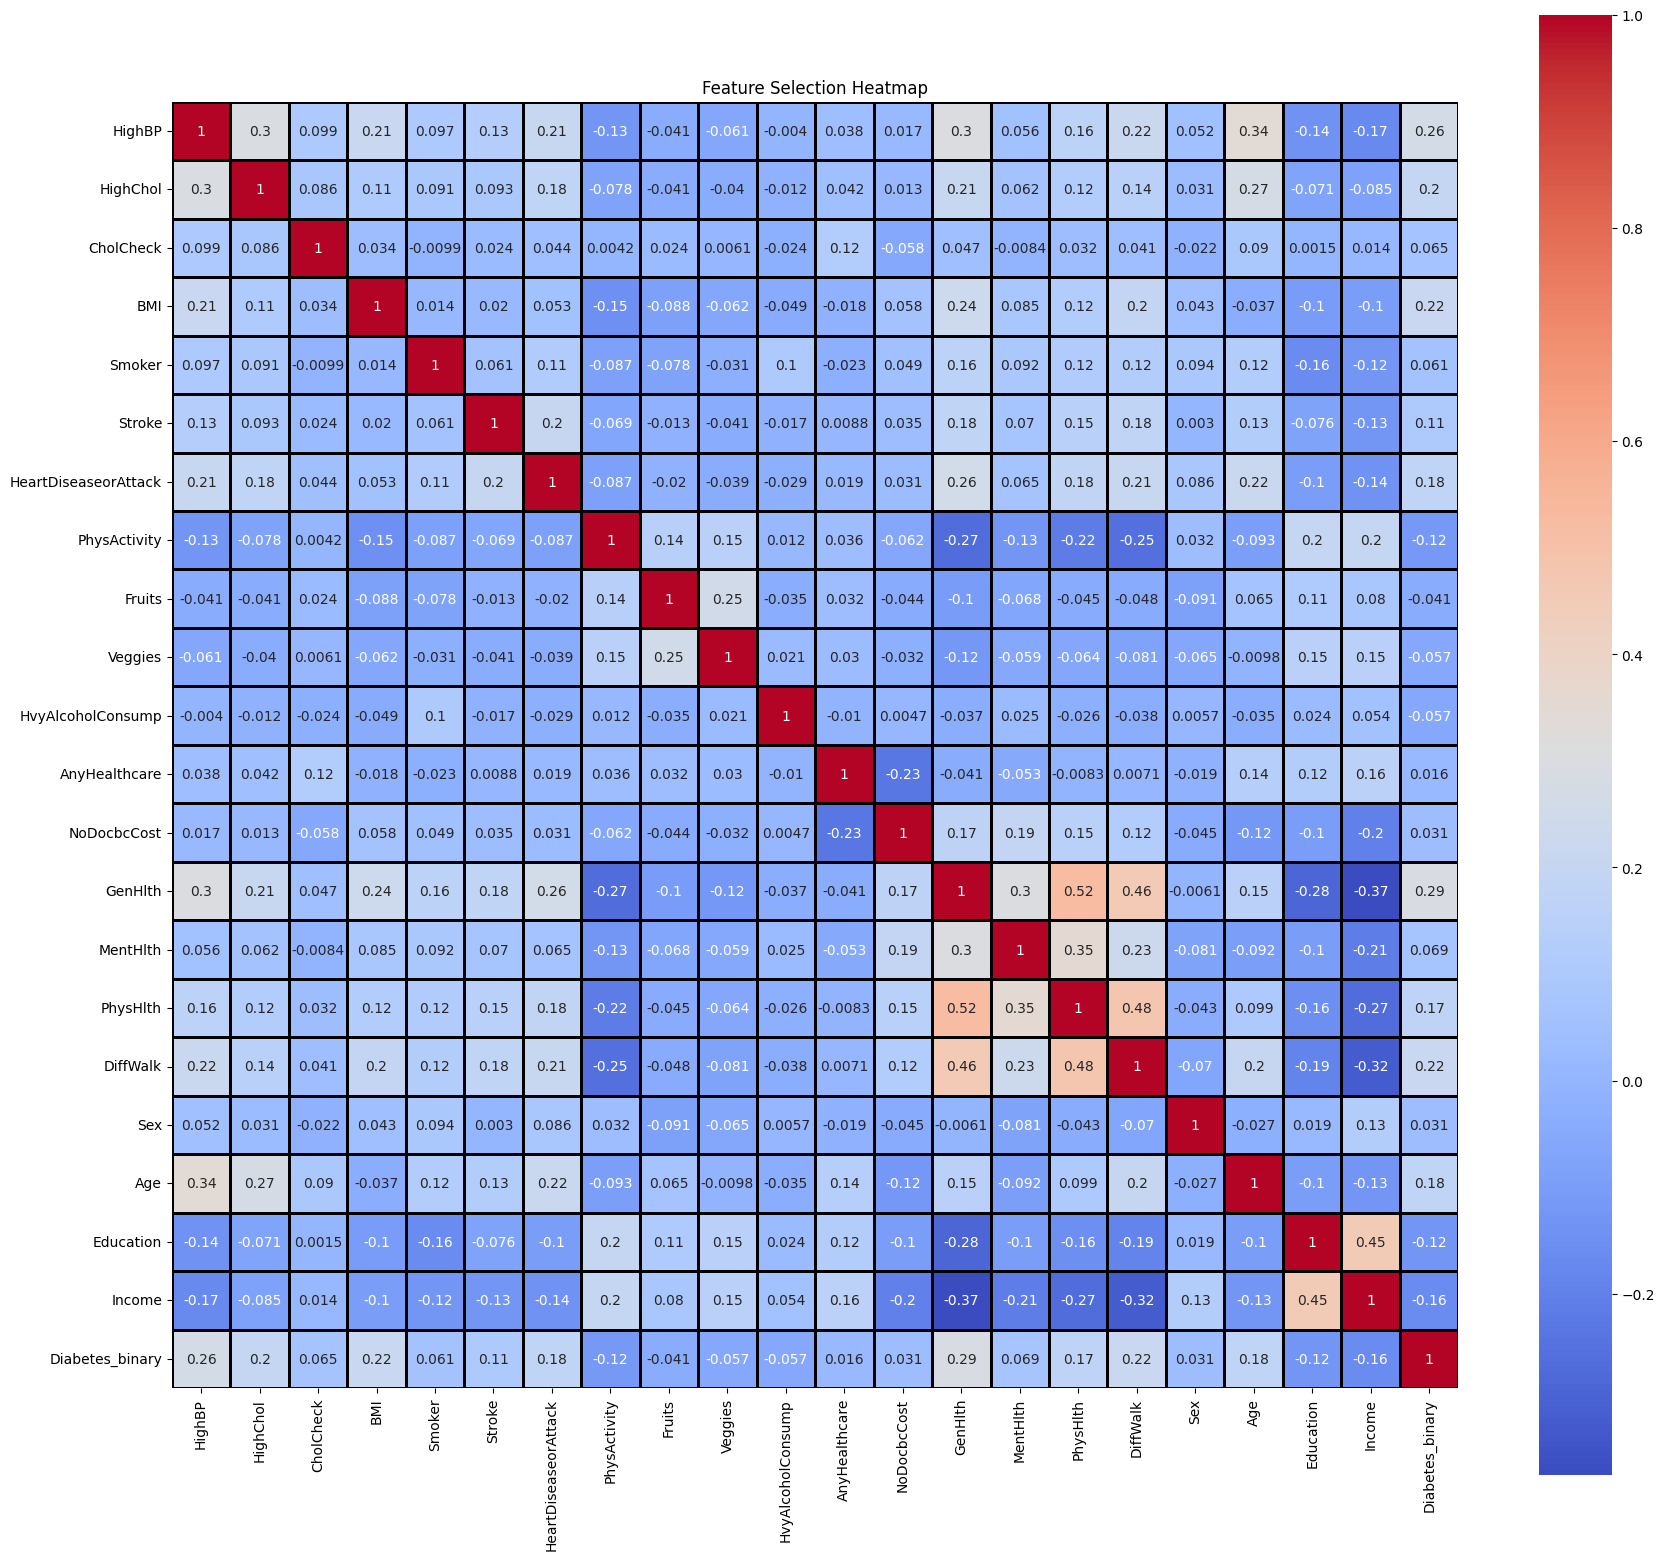

['GenHlth', 'HighBP', 'DiffWalk', 'BMI', 'HighChol', 'Age', 'HeartDiseaseorAttack', 'PhysHlth', 'Income', 'Education']


In [4]:
# Finding the features in the dataset: 

data_columns = diabetes_data.columns.to_list()
print("Features: ", data_columns)

# Plotting a correlation heatmap:

data_corr_matrix = diabetes_data.corr()
print(data_corr_matrix)
plt.figure(figsize=(18, 16))
sns.heatmap(data_corr_matrix, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=2, linecolor="Black")
plt.title("Feature Selection Heatmap")
plt.tight_layout()
plt.show()

# Feature selection: determining the correlations with the target column, Diabetes_binary: 

target_col = data_corr_matrix["Diabetes_binary"].drop("Diabetes_binary")
feature_selection = target_col.abs().sort_values(ascending=False)
top_10_features = feature_selection.head(10).index.to_list()
print(top_10_features)


In [ ]:
# Support Vector Machines (SVM) Model (retrieved codes from: https://www.datacamp.com/tutorial/svm-classification-scikit-learn-python): 

# Splitting the dataset: 

from sklearn.svm import LinearSVC

X = diabetes_data[top_10_features]
y = diabetes_data["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42) 

# Standardization of the data:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating an SVM Classifier (linear kernel):

svm_clf = LinearSVC(max_iter=10000, random_state=42, class_weight = "balanced")   # Link: https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
                                                                                 # Link: https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
# Training the model using the training sets:

svm_clf.fit(X_train_scaled, y_train)

# Predicting the response for the test dataset:
 
y_pred = svm_clf.predict(X_test_scaled)

# Model Accuracy: 

print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

# Model Precision: 

print("Precision:",metrics.precision_score(y_test, y_pred))

# Model Recall: 

print("Recall:",metrics.recall_score(y_test, y_pred))


Accuracy: 0.7251655629139073
Precision: 0.3044343483648106
Recall: 0.7722640251452519


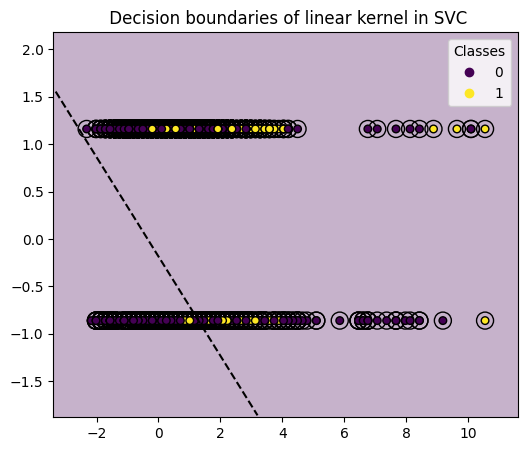

In [28]:
# Plotting the SVM Model (link: https://scikit-learn.org/stable/auto_examples/svm/plot_svm_kernels.html): 

# Chose two of the highest correlated features from the dataset: 

from sklearn import svm

X1 = diabetes_data[["BMI", "HighChol"]].values   
y1 = diabetes_data["Diabetes_binary"].values

X1, _, y1, _ = train_test_split(X1, y1, train_size=10000, random_state=42)

# Scaling the features:

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

# Defining the plot training data and training the SVM Model: 

def plot_training_data_with_decision_boundary(kernel="linear", ax=None, long_title=True, support_vectors=True):
    clf_1 = SVC(kernel=kernel, gamma=2)
    clf_1.fit(X1_scaled, y1)

    # Plotting settings:
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Plot decision boundary
    DecisionBoundaryDisplay.from_estimator(
        clf_1, X1_scaled, ax=ax,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3
    )
    DecisionBoundaryDisplay.from_estimator(
        clf_1, X1_scaled, ax=ax,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"]
    )
    
    ax.scatter(clf_1.support_vectors_[:, 0], clf_1.support_vectors_[:, 1],
                   s=150, facecolors='none', edgecolors='k')

    # Plotting the SVM Model: 
    scatter = ax.scatter(X1_scaled[:, 0], X1_scaled[:, 1], c=y1, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    plt.tight_layout
    plt.show()
 
plot_training_data_with_decision_boundary("linear")      

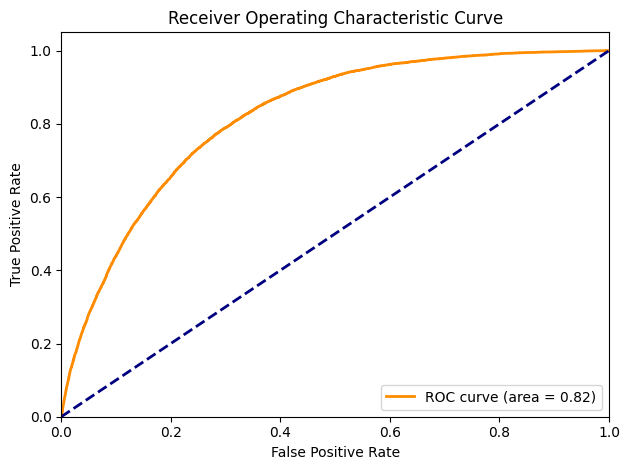

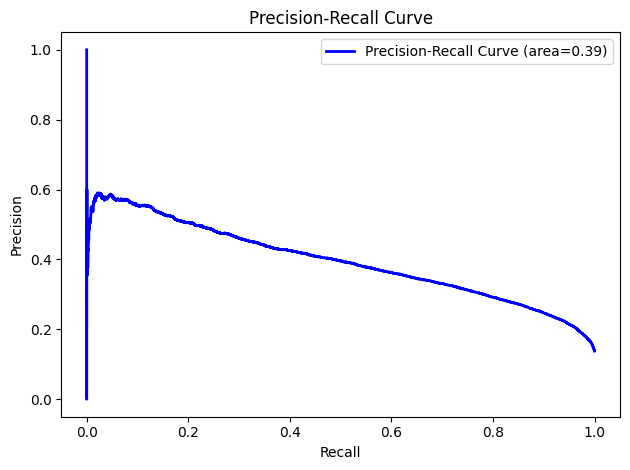

In [11]:
# AUROC Curve: 

y_scores = svm_clf.decision_function(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# AUPRC Curve: 

precision, recall, _ = precision_recall_curve(y_test, y_scores)
average_precision = average_precision_score(y_test, y_scores)

plt.figure()
plt.plot(recall, precision, color="blue", lw=2, label="Precision-Recall Curve (area=%0.2f)" % average_precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()